In [ ]:
!pip -q install mtcnn opencv-python matplotlib pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.1 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from google.colab import files

In [ ]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("image:/content/another_image2.jpg")

Saving group_photo.jpg to group_photo.jpg
image:/content/another_image2.jpg


In [ ]:
import matplotlib.pyplot as plt

def detect_and_crop(image_path, required_size=(160,160)):

    detector = MTCNN()

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        print("No face detected in:", image_path)
        return None

    x, y, w, h = results[0]['box']
    x, y = max(0,x), max(0,y)

    # GREEN BOX
    cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0,255,0), 3)

    face = img_rgb[y:y+h, x:x+w]
    face = cv2.resize(face, required_size)

    face = face.astype('float32')
    mean, std = face.mean(), face.std()
    face = (face - mean) / (std + 1e-6)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title("Detected Face")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow((face - face.min())/(face.max()-face.min()))
    plt.title("Cropped Face")
    plt.axis('off')
    plt.show()

    return face

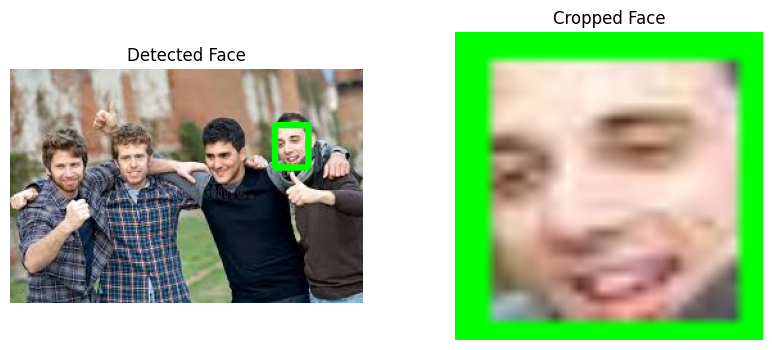

Face detected!
Face shape: (160, 160, 3)


In [ ]:
face = detect_and_crop(image_path)

if face is not None:
    print("Face detected!")
    print("Face shape:", face.shape)
else:
    print("No face detected.")

In [ ]:
def detect_and_crop(image_path, required_size=(160,160)):

    detector = MTCNN()

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        print("No face detected in:", image_path)
        return []

    faces = []

    for result in results:

        x, y, w, h = result['box']
        x, y = max(0, x), max(0, y)

        # Draw green box for each face
        cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0,255,0), 3)

        face = img_rgb[y:y+h, x:x+w]
        face = cv2.resize(face, required_size)

        face = face.astype('float32')
        mean, std = face.mean(), face.std()
        face = (face - mean) / (std + 1e-6)

        faces.append(face)

    # Show result
    plt.figure(figsize=(8,6))
    plt.imshow(img_rgb)
    plt.title(f"{len(faces)} Faces Detected")
    plt.axis('off')
    plt.show()

    return faces

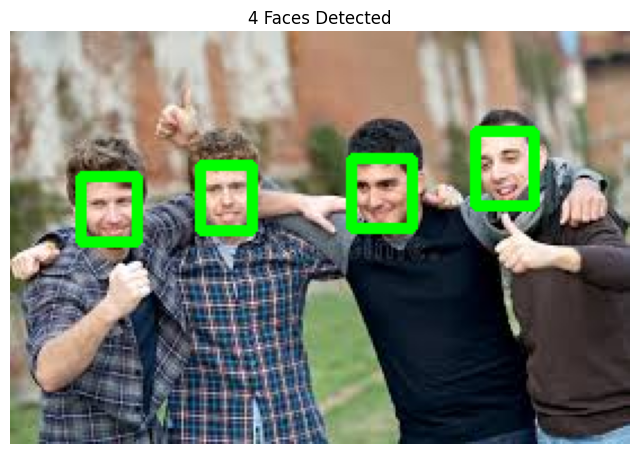

Faces detected: 4
Face 1 shape: (160, 160, 3)
Face 2 shape: (160, 160, 3)
Face 3 shape: (160, 160, 3)
Face 4 shape: (160, 160, 3)


In [ ]:
faces = detect_and_crop(image_path)

if len(faces) > 0:
    print("Faces detected:", len(faces))

    for i, face in enumerate(faces):
        print(f"Face {i+1} shape:", face.shape)
else:
    print("No face detected.")

In [ ]:
import matplotlib.pyplot as plt

def detect_and_crop(image_path, required_size=(160,160)):

    detector = MTCNN()

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        print("No face detected in:", image_path)
        return []

    cropped_faces = []

    # LOOP over all detected faces
    for result in results:
        x, y, w, h = result['box']
        x, y = max(0,x), max(0,y)

        # Draw green rectangle
        cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (0,255,0), 3)

        # Crop face
        face = img_rgb[y:y+h, x:x+w]
        face = cv2.resize(face, required_size)

        # Normalize (FaceNet)
        face = face.astype('float32')
        mean, std = face.mean(), face.std()
        face = (face - mean) / (std + 1e-6)

        cropped_faces.append(face)

    # --------- DISPLAY ----------
    plt.figure(figsize=(12,5))

    # Show detection image
    plt.subplot(1, len(cropped_faces)+1, 1)
    plt.imshow(img_rgb)
    plt.title("Detected Faces")
    plt.axis('off')

    # Show all cropped faces
    for i, face in enumerate(cropped_faces):
        plt.subplot(1, len(cropped_faces)+1, i+2)
        plt.imshow((face - face.min())/(face.max()-face.min()))
        plt.title(f"Face {i+1}")
        plt.axis('off')

    plt.show()

    return cropped_faces

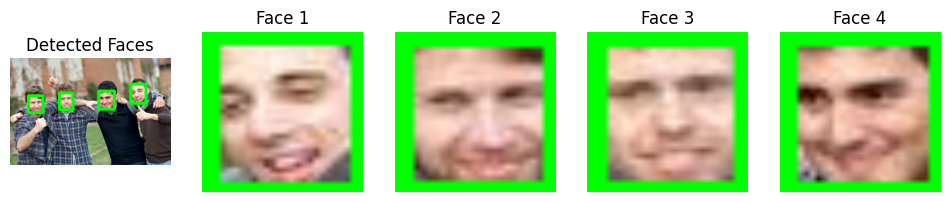

In [ ]:
faces = detect_and_crop(image_path)